In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Features categories
popularity_cols = ['track_popularity']
era_cols = ['Early Years', 'Classic Era', 'Golden Era', '2000s', 'Modern Era']
length_cols = ['Short', 'Medium', 'Long']
sentiment_cols = ['joy', 'calm', 'sadness', 'fear', 'energizing', 'dreamy']
genre_cols = ['Instrumental / Ambient Sounds', 'Soft Acoustic / Classical', 'Orchestral / Soundtrack',
              'Mid-tempo Pop / Indie', 'Upbeat Electronic / Dance', 'Slow & Melancholic (Sad Songs)',
              'Experimental / Jazz Fusion', 'Lo-Fi / Chill Vibes']

all_feature_cols = popularity_cols + era_cols + length_cols + sentiment_cols + genre_cols

def compute_track_similarity(hidden_tracks, recommended_tracks):
    # Combine datasets for consistent scaling
    all_tracks = pd.concat([hidden_tracks, recommended_tracks], ignore_index=True)

    # Normalize numerical feature (track popularity)
    # scaler = MinMaxScaler()
    # all_tracks[popularity_cols] = scaler.fit_transform(all_tracks[popularity_cols])

    # Ensure missing columns are added (in case a dataset lacks some categories)
    for col in era_cols + length_cols + sentiment_cols + genre_cols:
        if col not in all_tracks.columns:
            all_tracks[col] = 0  # Add missing columns with default value 0

    # Extract feature matrix
    feature_matrix = all_tracks[all_feature_cols].values

    # Compute cosine similarity matrix between hidden and recommended tracks
    similarity_matrix = cosine_similarity(feature_matrix[:len(hidden_tracks)], feature_matrix[len(hidden_tracks):])

    return similarity_matrix


In [6]:
full_track_pool

,track_idx,album_idx,artist_idx,track_popularity,2000s,Classic Era,Early Years,Golden Era,Modern Era,Long,...,Upbeat Electronic / Dance,Slow & Melancholic (Sad Songs),Experimental / Jazz Fusion,Lo-Fi / Chill Vibes,joy,calm,sadness,fear,energizing,dreamy
0,0,78824,20091,17,False,False,False,False,True,True,...,0.008577,0.029915,0.001412,0.003695,0.001485,0.006821,0.337886,0.325006,0.189776,0.139026
1,1,19030,26382,18,True,False,False,False,False,False,...,0.051727,0.011454,0.006616,0.002188,0.071933,0.054276,0.195337,0.185635,0.280816,0.212002
2,2,80563,1633,20,False,False,False,False,True,False,...,0.000054,0.015816,0.000255,0.942663,0.062012,0.049055,0.226615,0.224656,0.268122,0.169541
3,3,118169,47069,41,False,False,False,False,True,True,...,0.022019,0.009704,0.003267,0.001859,0.011911,0.003269,0.253698,0.244075,0.297410,0.189637
4,4,55985,4863,5,False,False,False,False,True,True,...,0.008952,0.050606,0.000693,0.002367,0.017030,0.010752,0.253036,0.265472,0.220705,0.233005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250421,252231,119490,51675,4,True,False,False,False,False,False,...,0.004673,0.003321,0.048602,0.030327,0.240892,0.027550,0.028927,0.021623,0.387898,0.293111
250422,252232,47583,50520,37,False,False,False,False,True,False,...,0.031401,0.006952,0.003040,0.001031,0.001059,0.005020,0.364300,0.321706,0.134650,0.173265
250423,252233,41843,32287,19,False,False,False,False,True,False,...,0.038996,0.013515,0.000879,0.000455,0.060215,0.085512,0.222417,0.176645,0.266088,0.189123
250424,252234,91014,45639,29,False,True,False,False,False,True,...,0.045454,0.010833,0.003158,0.001171,0.101683,0.097876,0.197815,0.146441,0.237738,0.218446


In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

full_track_pool = pd.read_csv("phase5_model_development/dataset/tracks_new.csv")
full_track_pool["track_popularity"] = full_track_pool["track_popularity"] / 100
# 1. Randomly sample 50 tracks from your DataFrame
sampled_tracks = full_track_pool.sample(n=50, random_state=42).reset_index(drop=True)

# 3. Extract only the feature matrix
feature_matrix = sampled_tracks[all_feature_cols].values

# 4. Compute cosine similarity between all pairs in the 50 tracks
similarity_matrix = cosine_similarity(feature_matrix)

# 5. Convert to DataFrame (optional, for nice display)
similarity_df = pd.DataFrame(similarity_matrix, index=sampled_tracks.index, columns=sampled_tracks.index)

# 6. View the result
print(similarity_df.head())

         0         1         2         3         4         5         6   \
0  1.000000  0.560409  0.223891  0.207265  0.076569  0.751278  0.096424   
1  0.560409  1.000000  0.638894  0.584056  0.481675  0.522557  0.174216   
2  0.223891  0.638894  1.000000  0.979957  0.819375  0.174934  0.478674   
3  0.207265  0.584056  0.979957  1.000000  0.806152  0.127215  0.458329   
4  0.076569  0.481675  0.819375  0.806152  1.000000  0.134757  0.442810   

         7         8         9   ...        40        41        42        43  \
0  0.131746  0.165974  0.084576  ...  0.238159  0.064565  0.575178  0.199805   
1  0.498924  0.421199  0.219064  ...  0.573484  0.428439  0.607845  0.567699   
2  0.799549  0.432108  0.181079  ...  0.953541  0.770229  0.289658  0.615950   
3  0.777941  0.430125  0.133631  ...  0.963073  0.768483  0.252969  0.601820   
4  0.739979  0.588874  0.168734  ...  0.773945  0.739950  0.137053  0.469242   

         44        45        46        47        48        49  
0  0

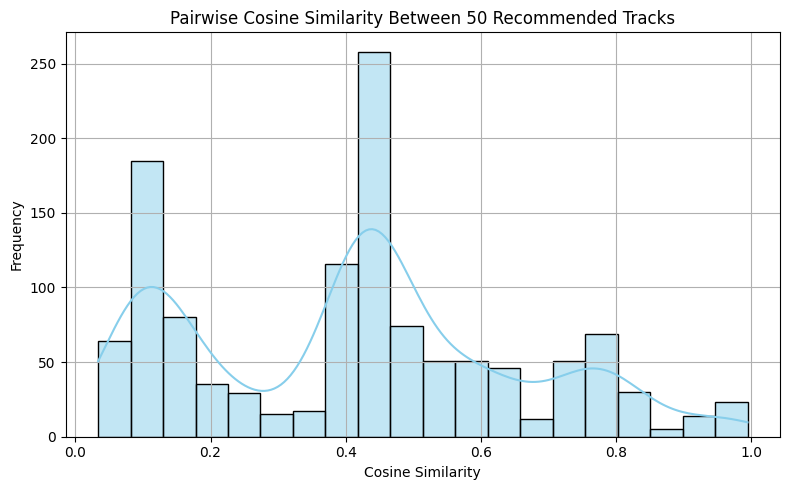

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute upper triangle (excluding diagonal) of similarity matrix
upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
similarity_scores = similarity_matrix[upper_triangle_indices]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(similarity_scores, bins=20, kde=True, color='skyblue')
plt.title('Pairwise Cosine Similarity Between 50 Recommended Tracks')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
avg_similarity = np.mean(similarity_matrix[np.triu_indices(50, k=1)])  # exclude diagonal
diversity_score = 1 - avg_similarity
print(diversity_score)

0.5864666722572082


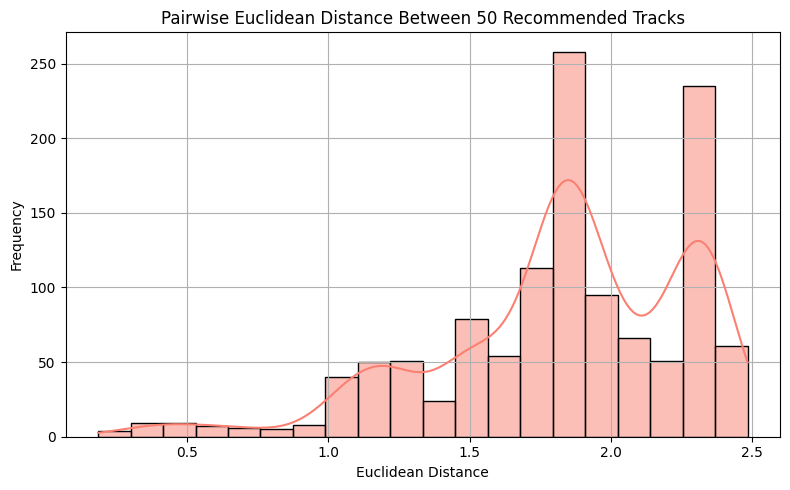

In [10]:
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Extract feature matrix (if you haven't already)
feature_matrix = sampled_tracks[all_feature_cols].values

# 2. Compute pairwise Euclidean distances (50 × 50 matrix)
distance_matrix = euclidean_distances(feature_matrix)

# 3. Extract upper triangle (excluding diagonal)
upper_triangle_indices = np.triu_indices_from(distance_matrix, k=1)
distance_scores = distance_matrix[upper_triangle_indices]

# 4. Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(distance_scores, bins=20, kde=True, color='salmon')
plt.title('Pairwise Euclidean Distance Between 50 Recommended Tracks')
plt.xlabel('Euclidean Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
print("Average distance:", np.mean(distance_scores))

Average distance: 1.8236007888606312


In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics.pairwise import cosine_similarity

# # Feature categories
# popularity_cols = ['track_popularity']
# era_cols = ['Early Years', 'Classic Era', 'Golden Era', '2000s', 'Modern Era']
# length_cols = ['Short', 'Medium', 'Long']
# sentiment_cols = ['joy', 'calm', 'sadness', 'fear', 'energizing', 'dreamy']
# genre_cols = ['Instrumental / Ambient Sounds', 'Soft Acoustic / Classical', 'Orchestral / Soundtrack',
#               'Mid-tempo Pop / Indie', 'Upbeat Electronic / Dance', 'Slow & Melancholic (Sad Songs)',
#               'Experimental / Jazz Fusion', 'Lo-Fi / Chill Vibes']

# feature_groups = {
#     "popularity": popularity_cols,
#     "era": era_cols,
#     "length": length_cols,
#     "sentiment": sentiment_cols,
#     "genre": genre_cols
# }

# def compute_track_similarity(hidden_tracks, recommended_tracks):
#     # Combine datasets for consistent scaling
#     all_tracks = pd.concat([hidden_tracks, recommended_tracks], ignore_index=True)

#     # Normalize popularity feature
#     scaler = MinMaxScaler()
#     all_tracks[popularity_cols] = scaler.fit_transform(all_tracks[popularity_cols])

#     # Ensure all required columns exist
#     for col_list in feature_groups.values():
#         for col in col_list:
#             if col not in all_tracks.columns:
#                 all_tracks[col] = 0  # Add missing columns with default value 0

#     # Compute cosine similarity for each feature group separately
#     similarity_scores = []
    
#     for feature_name, feature_cols in feature_groups.items():
#         feature_matrix = all_tracks[feature_cols].values
#         similarity = cosine_similarity(feature_matrix[:len(hidden_tracks)], feature_matrix[len(hidden_tracks):])
#         similarity_scores.append(similarity)
    
#     # Compute final similarity by averaging across all categories
#     final_similarity = np.mean(similarity_scores, axis=0)

#     return final_similarity

In [ ]:
# df = pd.read_csv("phase5_model_development/dataset/tracks_new.csv")
# # Set the highest value in each row to 1, and the rest to 0 for genre and sentiment
# df[genre_cols] = (df[genre_cols].eq(df[genre_cols].max(axis=1), axis=0)).astype(int)
# df[sentiment_cols] = (df[sentiment_cols].eq(df[sentiment_cols].max(axis=1), axis=0)).astype(int)

In [ ]:
# import pandas as pd
# import numpy as np

# # Randomly select 2 hidden tracks
# hidden_tracks = df.sample(n=2, random_state=42)
# # Select 3 recommended tracks from the remaining dataset
# recommended_tracks = df.drop(hidden_tracks.index).sample(n=3, random_state=42)

# # Show the selected tracks
# print("Hidden Tracks:")
# display(hidden_tracks)

# print("\nRecommended Tracks:")
# display(recommended_tracks)

# # Compute similarity
# similarity_matrix = compute_track_similarity(hidden_tracks, recommended_tracks)

# # Display results
# print("\nSimilarity Matrix:")
# print(pd.DataFrame(similarity_matrix, 
#                    index=[f'Hidden_{i+1}' for i in range(len(hidden_tracks))], 
#                    columns=[f'Rec_{i+1}' for i in range(len(recommended_tracks))]))

Hidden Tracks:


,track_idx,album_idx,artist_idx,track_popularity,2000s,Classic Era,Early Years,Golden Era,Modern Era,Long,...,Upbeat Electronic / Dance,Slow & Melancholic (Sad Songs),Experimental / Jazz Fusion,Lo-Fi / Chill Vibes,joy,calm,sadness,fear,energizing,dreamy
173568,174804,100141,13836,25,True,False,False,False,False,False,...,0,0,0,0,0,0,1,0,0,0
45316,45667,1072,1214,85,False,False,False,False,True,False,...,0,0,0,0,0,0,0,0,1,0



Recommended Tracks:


,track_idx,album_idx,artist_idx,track_popularity,2000s,Classic Era,Early Years,Golden Era,Modern Era,Long,...,Upbeat Electronic / Dance,Slow & Melancholic (Sad Songs),Experimental / Jazz Fusion,Lo-Fi / Chill Vibes,joy,calm,sadness,fear,energizing,dreamy
56368,56805,45858,44813,9,False,False,False,False,True,True,...,0,0,0,0,0,0,0,1,0,0
103125,103863,91918,53754,24,False,False,False,True,False,False,...,0,0,0,0,0,0,1,0,0,0
17088,17215,128433,28533,71,False,False,False,False,True,True,...,0,0,0,0,0,0,0,1,0,0



Similarity Matrix:
             Rec_1     Rec_2     Rec_3
Hidden_1  0.000000  0.505130  0.039538
Hidden_2  0.223607  0.266445  0.375951
